In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
cd C:\Users\Admin\sandbox\Portfolio\lost sales\retail store data

C:\Users\Admin\sandbox\Portfolio\lost sales\retail store data


In [4]:
df = pd.read_csv("feature_engineered_inventory_final.csv")

In [5]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Final price,Revenue,Remaining inventory,Inventory utilization %,Demand gap,Fulfillment Rate (%),Stockout,Overstock,Overstock flag
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn,26.800,3403.600,104,54.978355,8.47,93.747693,No,Yes,Yes
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn,50.408,7561.200,54,73.529412,-5.96,104.137740,No,Yes,Yes
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer,25.191,1637.415,37,63.725490,9.02,87.814104,No,Yes,Yes
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn,29.448,1796.328,408,13.006397,1.18,98.102284,No,Yes,Yes
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer,73.640,1030.960,152,8.433735,-4.74,151.187905,No,Yes,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     73100 non-null  str    
 1   Store ID                 73100 non-null  str    
 2   Product ID               73100 non-null  str    
 3   Category                 73100 non-null  str    
 4   Region                   73100 non-null  str    
 5   Inventory Level          73100 non-null  int64  
 6   Units Sold               73100 non-null  int64  
 7   Units Ordered            73100 non-null  int64  
 8   Demand Forecast          73100 non-null  float64
 9   Price                    73100 non-null  float64
 10  Discount                 73100 non-null  int64  
 11  Weather Condition        73100 non-null  str    
 12  Holiday/Promotion        73100 non-null  int64  
 13  Competitor Pricing       73100 non-null  float64
 14  Seasonality              73100 no

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
df["Date"].dtype

dtype('<M8[us]')

In [9]:
df.isnull().sum()

Date                         0
Store ID                     0
Product ID                   0
Category                     0
Region                       0
Inventory Level              0
Units Sold                   0
Units Ordered                0
Demand Forecast              0
Price                        0
Discount                     0
Weather Condition            0
Holiday/Promotion            0
Competitor Pricing           0
Seasonality                  0
Final price                  0
Revenue                      0
Remaining inventory          0
Inventory utilization %      0
Demand gap                   0
Fulfillment Rate (%)       673
Stockout                     0
Overstock                    0
Overstock flag               0
dtype: int64

here null values in Fulfillment rate are justifyable

In [10]:
df.shape

(73100, 24)

### Univarient analysis begins

In [11]:
df["Revenue"].describe()

count    73100.000000
mean      6771.154240
std       6815.600468
min          0.000000
25%       1811.012000
50%       4444.157500
75%       9520.222500
max      45467.446500
Name: Revenue, dtype: float64

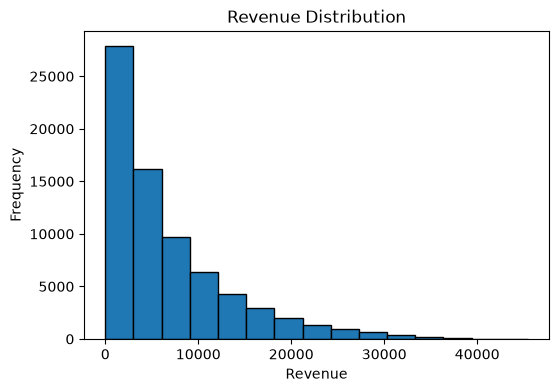

In [12]:
plt.figure(figsize = (6,4))
plt.hist(df["Revenue"], bins=15, edgecolor = "black")
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [13]:
df["Units Sold"].describe()

count    73100.000000
mean       136.464870
std        108.919406
min          0.000000
25%         49.000000
50%        107.000000
75%        203.000000
max        499.000000
Name: Units Sold, dtype: float64

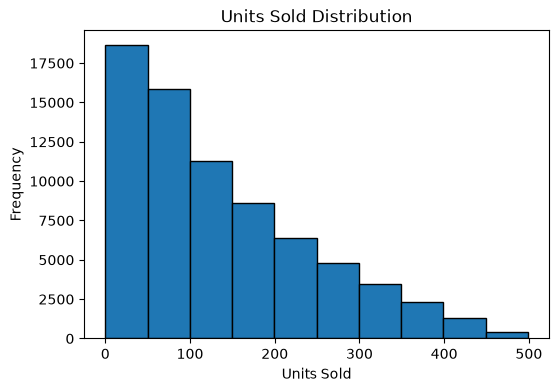

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df["Units Sold"], bins = 10, edgecolor="black")
plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6652\4020476065.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Units Sold"], vert=False)


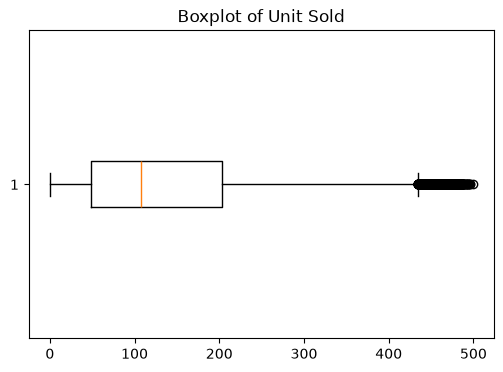

In [15]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Units Sold"], vert=False)
plt.title("Boxplot of Unit Sold")
plt.show()

In [16]:
# inventory
df["Inventory Level"].describe()

count    73100.000000
mean       274.469877
std        129.949514
min         50.000000
25%        162.000000
50%        273.000000
75%        387.000000
max        500.000000
Name: Inventory Level, dtype: float64

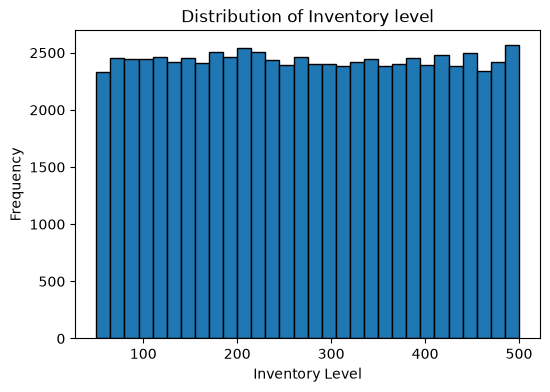

In [17]:
plt.figure(figsize=(6,4))
plt.hist(df["Inventory Level"], bins=30, edgecolor="black")
plt.title("Distribution of Inventory level")
plt.xlabel("Inventory Level")
plt.ylabel("Frequency")
plt.show()

In [18]:
df["Price"].describe()

count    73100.000000
mean        55.135108
std         26.021945
min         10.000000
25%         32.650000
50%         55.050000
75%         77.860000
max        100.000000
Name: Price, dtype: float64

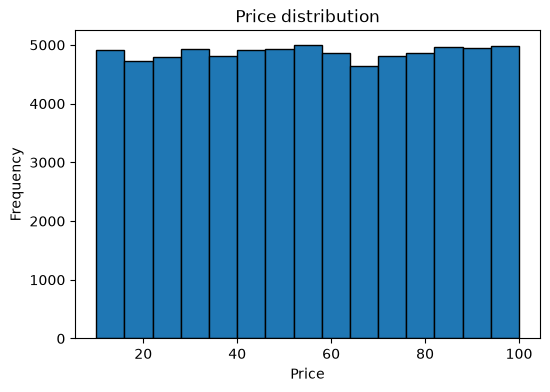

In [19]:
plt.figure(figsize=(6,4))
plt.hist(df["Price"], bins = 15, edgecolor = "black")
plt.title("Price distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

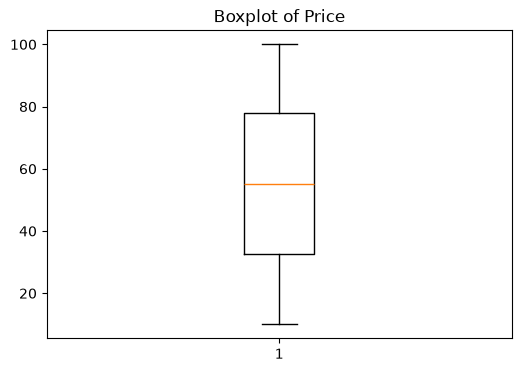

In [20]:

plt.figure(figsize=(6,4))
plt.boxplot(df["Price"])
plt.title("Boxplot of Price")
plt.show()

In [21]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Final price', 'Revenue',
       'Remaining inventory', 'Inventory utilization %', 'Demand gap',
       'Fulfillment Rate (%)', 'Stockout', 'Overstock', 'Overstock flag'],
      dtype='str')

In [22]:
df["Discount"].describe()

count    73100.000000
mean        10.009508
std          7.083746
min          0.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         20.000000
Name: Discount, dtype: float64

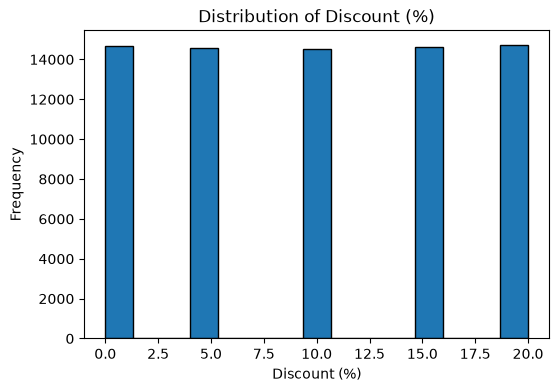

In [23]:
plt.figure(figsize=(6,4))
plt.hist(df["Discount"], bins=15, edgecolor="black")
plt.title("Distribution of Discount (%)")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6652\3489441273.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Discount"], vert=False)


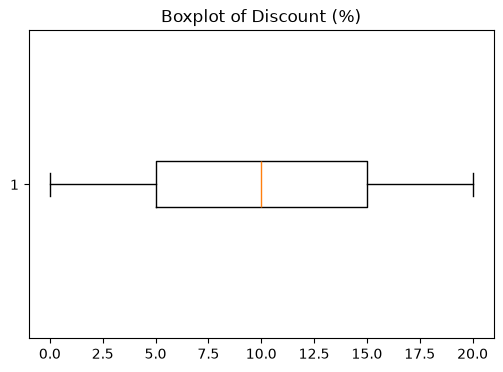

In [24]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Discount"], vert=False)
plt.title("Boxplot of Discount (%)")
plt.show()

### Renvenue leakage investagtion based on derived features

In [25]:
#firstly investegate the demand forecast of inventory
df["Demand Forecast"].describe()

count    73100.000000
mean       141.528727
std        109.209174
min          0.000000
25%         53.670000
50%        113.015000
75%        208.052500
max        518.550000
Name: Demand Forecast, dtype: float64

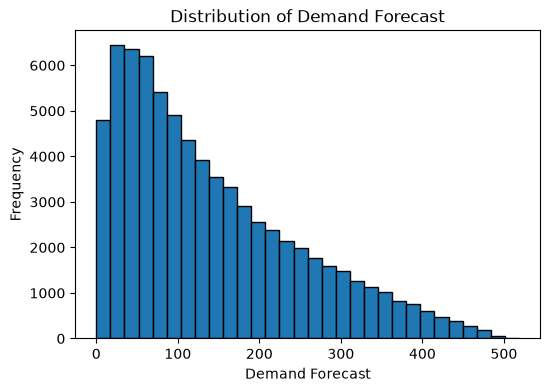

In [26]:
plt.figure(figsize=(6,4))
plt.hist(df["Demand Forecast"], bins=30, edgecolor="black")
plt.title("Distribution of Demand Forecast")
plt.xlabel("Demand Forecast")
plt.ylabel("Frequency")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6652\3239898576.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Demand Forecast"], vert=False)


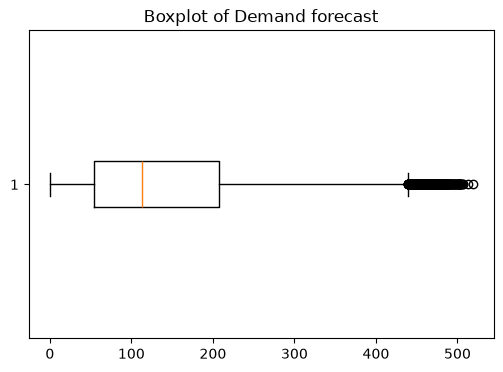

In [27]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Demand Forecast"], vert=False)
plt.title("Boxplot of Demand forecast")
plt.show()

In [28]:
print("Products with zero Demand forecast:", (df["Demand Forecast"] == 0).sum())

Products with zero Demand forecast: 673


based on previous analyses, we noted that we have 673 products with zero Demand forecast


In [29]:
#the derived demand gap
df["Demand gap"].describe()

count    73100.000000
mean         5.063857
std          8.622196
min        -10.000000
25%         -2.350000
50%          4.990000
75%         12.510000
max         20.000000
Name: Demand gap, dtype: float64

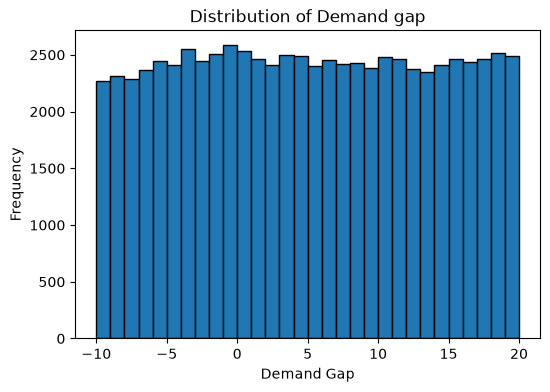

In [30]:
plt.figure(figsize=(6,4))
plt.hist(df["Demand gap"], bins=30, edgecolor="black")
plt.title("Distribution of Demand gap")
plt.xlabel("Demand Gap")
plt.ylabel("Frequency")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6652\2213447586.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Demand gap"], vert=False)


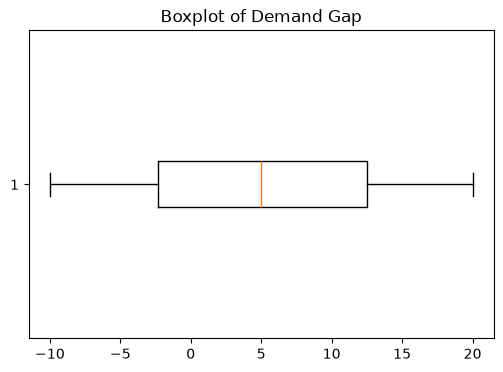

In [31]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Demand gap"], vert=False)
plt.title("Boxplot of Demand Gap")
plt.show()

In [32]:
print("Over expected Demand :", (df["Demand gap"] > 0).sum())
print("Correct Forecast     :", (df["Demand gap"] == 0).sum())
print("lower expected Demand:", (df["Demand gap"] < 0).sum())

Over expected Demand : 48783
Correct Forecast     : 157
lower expected Demand: 24160


In [33]:
#the fulfillment rate anlysis, also we have null values here so
df["Fulfillment Rate (%)"].describe()

count    72427.000000
mean       100.365557
std        263.072189
min          0.000000
25%         88.942758
50%         96.324461
75%        101.659021
max      50000.000000
Name: Fulfillment Rate (%), dtype: float64

In [34]:
print("Missing fulfillment rates:", df["Fulfillment Rate (%)"].isna().sum())

Missing fulfillment rates: 673


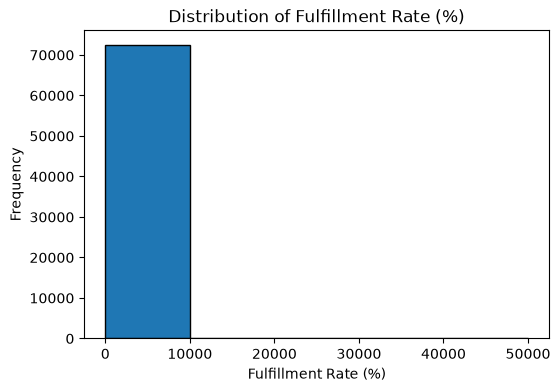

In [35]:
plt.figure(figsize=(6,4))
plt.hist(df["Fulfillment Rate (%)"].dropna(), bins=5, edgecolor="black")
plt.title("Distribution of Fulfillment Rate (%)")
plt.xlabel("Fulfillment Rate (%)")
plt.ylabel("Frequency")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_6652\2200026818.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Fulfillment Rate (%)"].dropna(), vert=False)


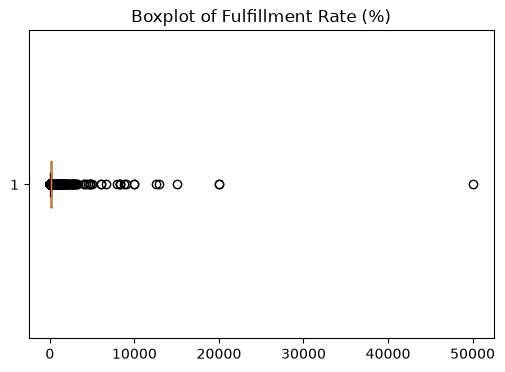

In [36]:
plt.figure(figsize=(6,4))
plt.boxplot(df["Fulfillment Rate (%)"].dropna(), vert=False)
plt.title("Boxplot of Fulfillment Rate (%)")
plt.show()

In [37]:
#overstock flag
df["Overstock flag"].value_counts()

Overstock flag
Yes    59037
No     14063
Name: count, dtype: int64

In [38]:
(df["Overstock flag"].value_counts(normalize=True) *100).round(2)

Overstock flag
Yes    80.76
No     19.24
Name: proportion, dtype: float64

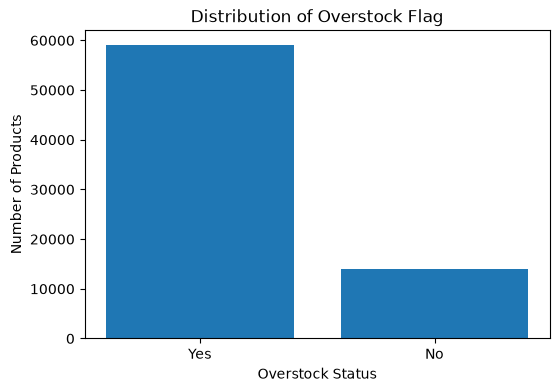

In [39]:
overstock_counts = df["Overstock flag"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(overstock_counts.index, overstock_counts.values)
plt.title("Distribution of Overstock Flag")
plt.xlabel("Overstock Status")
plt.ylabel("Number of Products")
plt.show()

In [40]:
#Stockout
df["Stockout"].value_counts()

Stockout
No     70515
Yes     2585
Name: count, dtype: int64

In [41]:
(df["Stockout"].value_counts(normalize=True) *100).round(2)

Stockout
No     96.46
Yes     3.54
Name: proportion, dtype: float64

so 96% of products doesnt meet demand and get out of stock

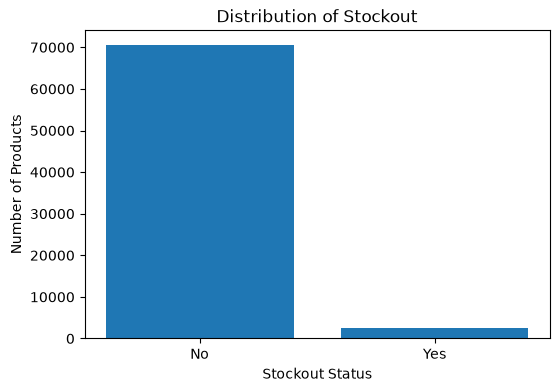

In [42]:
stockout_counts = df["Stockout"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(stockout_counts.index, stockout_counts.values)
plt.title("Distribution of Stockout")
plt.xlabel("Stockout Status")
plt.ylabel("Number of Products")
plt.show()

### Bivariate Business Analysis begins

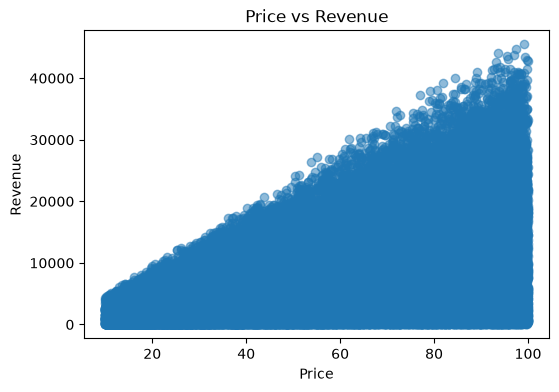

In [43]:
plt.figure(figsize=(6,4))
plt.scatter(df["Price"], df["Revenue"], alpha=0.5)
plt.title("Price vs Revenue")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.show()

In [44]:
df[["Price", "Revenue"]].corr()

,Price,Revenue
Price,1.000000,0.468666
Revenue,0.468666,1.000000


Does discousnt affects the units sold in inventory

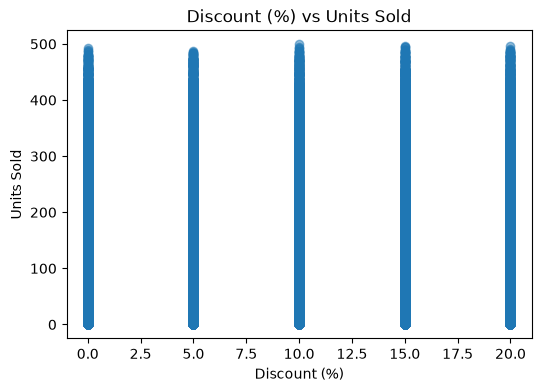

In [45]:
plt.figure(figsize=(6,4))
plt.scatter(df["Discount"], df["Units Sold"], alpha=0.5)
plt.title("Discount (%) vs Units Sold")
plt.xlabel("Discount (%)")
plt.ylabel("Units Sold")
plt.show()

In [46]:
df[["Discount", "Units Sold"]].corr()

,Discount,Units Sold
Discount,1.000000,0.002576
Units Sold,0.002576,1.000000


effect of higher inventory on the sales

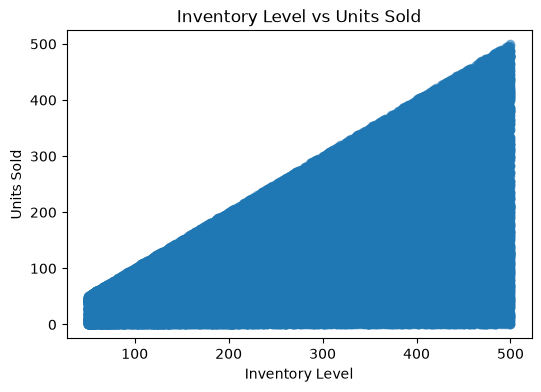

In [47]:
plt.figure(figsize=(6,4))
plt.scatter(df["Inventory Level"], df["Units Sold"], alpha=0.5)
plt.title("Inventory Level vs Units Sold")
plt.xlabel("Inventory Level")
plt.ylabel("Units Sold")
plt.show()

In [48]:
df[["Inventory Level", "Units Sold"]].corr()

,Inventory Level,Units Sold
Inventory Level,1.000000,0.589995
Units Sold,0.589995,1.000000


#### Revenue analysis based on the category
- Which category generates highest and lowest revenue

In [49]:
pd.set_option("display.float_format", "{:,.0f}".format) #full no. display

In [50]:
category_revenue = (
    df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
)
print(category_revenue)

Category
Furniture     100,230,824
Groceries      99,948,968
Toys           98,729,217
Clothing       98,676,780
Electronics    97,385,586
Name: Revenue, dtype: float64


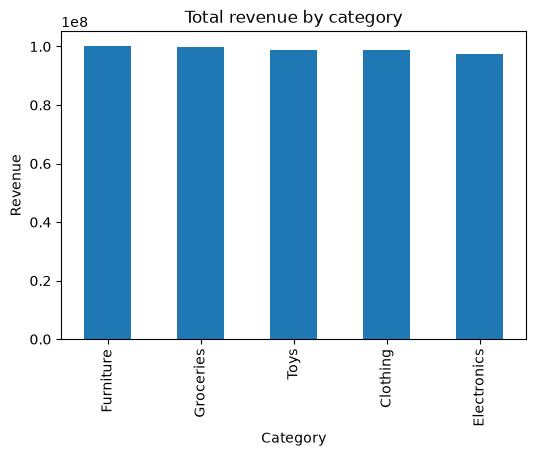

In [51]:
plt.figure(figsize=(6,4))
category_revenue.plot(kind="bar")
plt.title("Total revenue by category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

In [52]:
category_revenue.head(5)

Category
Furniture     100,230,824
Groceries      99,948,968
Toys           98,729,217
Clothing       98,676,780
Electronics    97,385,586
Name: Revenue, dtype: float64

In [53]:
category_revenue.tail(5)

Category
Furniture     100,230,824
Groceries      99,948,968
Toys           98,729,217
Clothing       98,676,780
Electronics    97,385,586
Name: Revenue, dtype: float64

In [54]:
df.groupby("Category")["Revenue"].mean().sort_values(ascending=False)

Category
Groceries     6,841
Furniture     6,819
Clothing      6,747
Toys          6,742
Electronics   6,707
Name: Revenue, dtype: float64

#### Stockout by Category
- Which categories have the most stockouts?

In [55]:
stockout_category = (
    df[df["Stockout"] == "Yes"].groupby("Category").size().sort_values(ascending=False)
)
print(stockout_category)

Category
Groceries      535
Furniture      524
Clothing       510
Electronics    508
Toys           508
dtype: int64


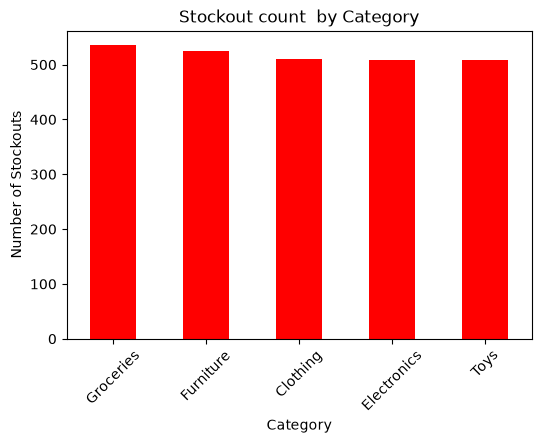

In [56]:
plt.figure(figsize=(6,4))
stockout_category.plot(kind="bar", color="red")
plt.title("Stockout count  by Category")
plt.xlabel("Category")
plt.ylabel("Number of Stockouts")
plt.xticks(rotation=45)
plt.show()

#### Category wise overstock analysis
- Which product categories got most affected by overstocking?

In [57]:
overstock_category = (
    df[df["Overstock flag"] == "Yes"].groupby("Category").size().sort_values(ascending=False)
)
print(overstock_category)

Category
Toys           11846
Furniture      11845
Groceries      11803
Clothing       11779
Electronics    11764
dtype: int64


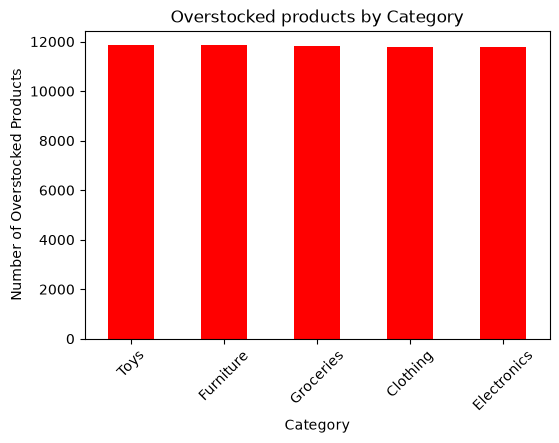

In [58]:
plt.figure(figsize=(6,4))
overstock_category.plot(kind="bar", color="red")
plt.title("Overstocked products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Overstocked Products")
plt.xticks(rotation=45)
plt.show()

plt.show()

In [60]:
df.groupby("Overstock flag")["Revenue"].agg(
    Total_Revenue="sum",
    Average_Revenue="mean",
    Product_Count="count"
)

,Total_Revenue,Average_Revenue,Product_Count
Overstock flag,,,
No,"165,417,281","11,763",14063
Yes,"329,554,094","5,582",59037


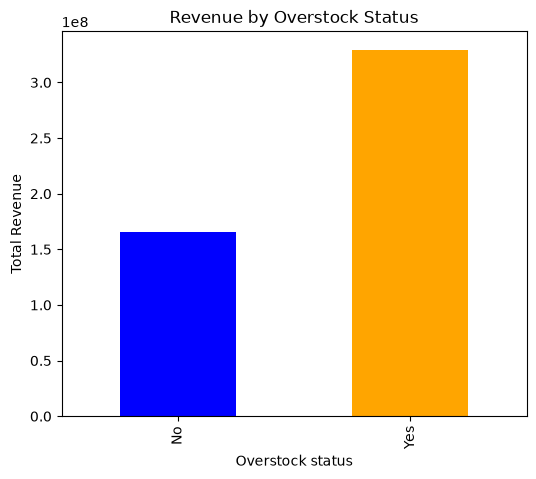

In [63]:
overstock_revenue = (
    df.groupby("Overstock flag")["Revenue"]
      .sum()
)

plt.figure(figsize=(6,5))
overstock_revenue.plot(kind="bar", color=["blue", "orange"])
plt.title("Revenue by Overstock Status")
plt.xlabel("Overstock status")
plt.ylabel("Total Revenue")
plt.show()

#### Revenue by Stockout Status
- does stockout products contributes in high revenue products

In [67]:
stockout_revenue = df.groupby("Stockout")["Revenue"].agg(
    Total_Revenue="sum",
    Average_Revenue="mean",
    Product_Count="count"
)

stockout_revenue

,Total_Revenue,Average_Revenue,Product_Count
Stockout,,,
No,"470,862,935","6,677",70515
Yes,"24,108,440","9,326",2585


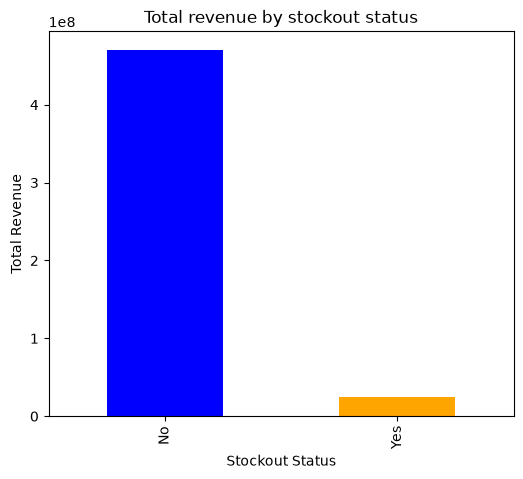

In [69]:
plt.figure(figsize=(6,5))
df.groupby("Stockout")["Revenue"].sum().plot(kind="bar",color=["blue", "orange"]
)
plt.title("Total revenue by stockout status")
plt.xlabel("Stockout Status")
plt.ylabel("Total Revenue")
plt.show()

In [72]:
df.groupby("Stockout")["Revenue"].describe()

,count,mean,std,min,25%,50%,75%,max
Stockout,,,,,,,,
No,"70,515","6,677","6,745",0,"1,765","4,370","9,403","44,664"
Yes,"2,585","9,326","8,118",417,"3,399","6,495","12,682","45,467"


#### FulDoes better fulfillment lead to higher revenue?fillment Rate vs Revenue
- Does better fulfillment causes higher revenue?

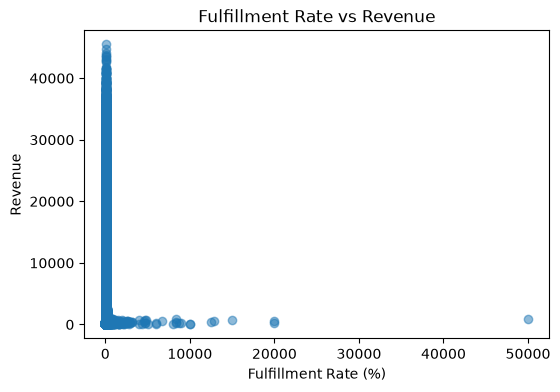

In [75]:
plt.figure(figsize=(6,4))
plt.scatter(
    df["Fulfillment Rate (%)"],
    df["Revenue"],
    alpha=0.5
)
plt.title("Fulfillment Rate vs Revenue")
plt.xlabel("Fulfillment Rate (%)")
plt.ylabel("Revenue")
plt.show()

#### Demand Gap vs Revenue
- Does inacorrect demand forecasting impact revenue?

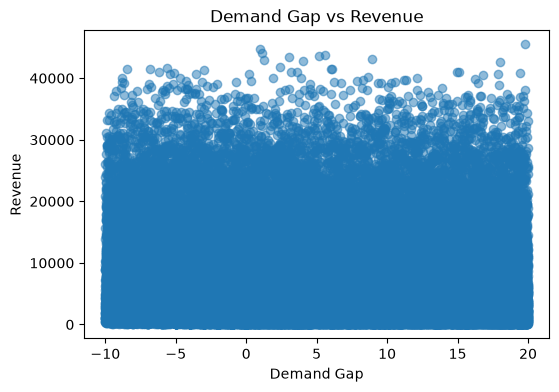

In [78]:
plt.figure(figsize=(6,4))
plt.scatter(
    df["Demand gap"],
    df["Revenue"],
    alpha=0.5
)
plt.title("Demand Gap vs Revenue")
plt.xlabel("Demand Gap")
plt.ylabel("Revenue")
plt.show()

### Top 10 Products by Revenue

In [79]:
top_products = (
    df.groupby("Product ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product ID
P0020   25,502,320
P0011   25,456,724
P0016   25,319,508
P0014   25,268,815
P0005   25,164,517
P0013   25,117,342
P0015   24,946,851
P0009   24,829,627
P0007   24,782,960
P0004   24,729,108
Name: Revenue, dtype: float64


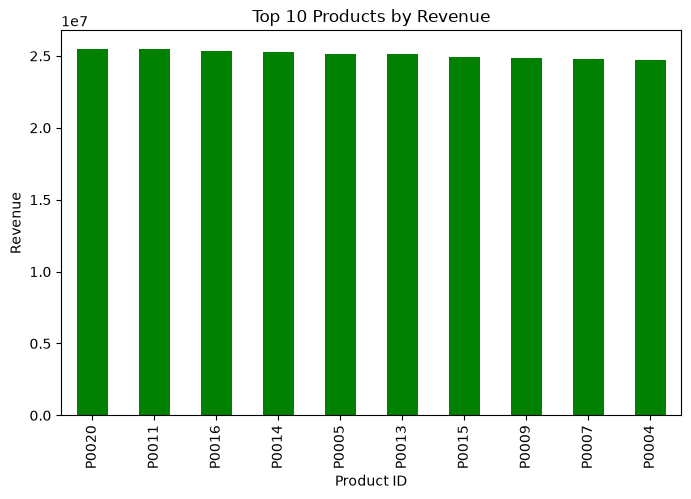

In [81]:
plt.figure(figsize=(8,5))
top_products.plot(kind="bar", color="green")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Revenue")
plt.show()

#### products that have highrevenue but also have stockouts

In [83]:
top_stockout_products = (
    df[df["Stockout"] == "Yes"]
      .groupby("Product ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print(top_stockout_products)

Product ID
P0008   1,450,620
P0019   1,437,104
P0004   1,359,743
P0010   1,313,188
P0001   1,294,311
P0009   1,281,935
P0013   1,272,157
P0003   1,246,566
P0005   1,219,505
P0007   1,210,759
Name: Revenue, dtype: float64
